# AFM Similarity Search — Ingestion Pipeline
**Purpose:** Load `.ibw` AFM files, preprocess height maps, extract metadata, and generate CLIP embeddings for both image and text. The output of this notebook is a record per file containing everything needed to populate the vector database in the next stage.

**Pipeline stages:**
```
.ibw file
    │
    ├─► [1] Load raw data + metadata          (igor2)
    │
    ├─► [2] Visualize all 4 channels          (matplotlib)
    │
    ├─► [3] Preprocess height map             (plane-level → normalize → resize to 224×224)
    │
    ├─► [4] Visualize preprocessing steps     (before/after each step)
    │
    ├─► [5] Extract & structure metadata      (parse IBW note → dict → semantic text)
    │
    ├─► [6] Generate image embedding          (CLIP ViT-B/32 image encoder)
    │
    ├─► [7] Generate text embedding           (CLIP text encoder on metadata string)
    │
    ├─► [8] Visualize embedding space         (cosine similarity, vector inspection)
    │
    └─► [9] Package ingestion record          (all outputs bundled for vector DB)
```

## 1. Imports & Configuration

In [ ]:
# ── Standard scientific stack ───────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

# ── Image processing ────────────────────────────────────────────
from scipy.ndimage import gaussian_filter
from skimage.transform import resize

# ── CLIP ────────────────────────────────────────────────────────
# Install if needed:  pip install git+https://github.com/openai/CLIP.git
# Also requires:      pip install torch torchvision
import torch
import clip
from PIL import Image

# ── IBW loading ────────────
import igor2

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print(f"PyTorch version : {torch.__version__}")
print(f"CLIP available  : {clip is not None}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device          : {device}")

PyTorch version : 2.10.0+cpu
CLIP available  : True
Device          : cpu


## 2. User Configuration

Set the file path and any known sample context here. The `USER_TEXT` field is what a researcher would type when ingesting a file — it supplements the automatically parsed metadata and becomes part of the text embedding.

In [13]:
# ── File to ingest ──────────────────────────────────────────────
FILE_PATH  = "GV0130001.ibw"

# ── User-supplied sample context (free text) ────────────────────
# This is the text a researcher provides when adding a file to the database.
# It will be combined with parsed metadata to form the full text embedding.
USER_TEXT  = "SrTiO3 thin film on SrTiO3 substrate, tapping mode, ambient conditions"

# ── Instrument channel map (standard Asylum Research order) ─────
CHANNEL_NAMES = {0: "Height", 1: "Deflection", 2: "Amplitude", 3: "Phase"}
HEIGHT_CH     = 0

# ── Preprocessing parameters ────────────────────────────────────
CLIP_IMG_SIZE   = 224        # CLIP expects 224×224 RGB input
GAUSS_SIGMA     = 0.8        # mild smoothing before embedding (removes detector noise)

print("Configuration loaded.")
print(f"  File      : {FILE_PATH}")
print(f"  User text : {USER_TEXT}")

Configuration loaded.
  File      : GV0130001.ibw
  User text : SrTiO3 thin film on SrTiO3 substrate, tapping mode, ambient conditions


## 3. Load IBW File

Using the same `igor2` loading pattern from your existing AFM notebook. We extract the full 4-channel data array and the raw metadata note string.

In [ ]:
# ── Load binary wave ────────────────────────────────────────────
ibw      = igor2.binarywave.load(FILE_PATH)
data     = ibw['wave']['wData']       # shape: (rows, cols, channels)
raw_note = ibw['wave']['note']

n_rows, n_cols, n_channels = data.shape
print(f"Data shape  : {data.shape}  →  {n_rows}×{n_cols} px, {n_channels} channels")
print(f"Data dtype  : {data.dtype}")

# ── Extract all channels ──────
height    = data[:, :, 0] / 1e-9     # convert m → nm
defl      = data[:, :, 1]
amplitude = data[:, :, 2]
phase     = data[:, :, 3]

print(f"Height range: {height.min():.3f} – {height.max():.3f} nm")

Data shape  : (256, 256, 4)  →  256×256 px, 4 channels
Data dtype  : float32
Height range: -1.397 – 3.608 nm


## 4. Visualize All Raw Channels

Displaying all four channels before any processing. This is the raw instrument output.

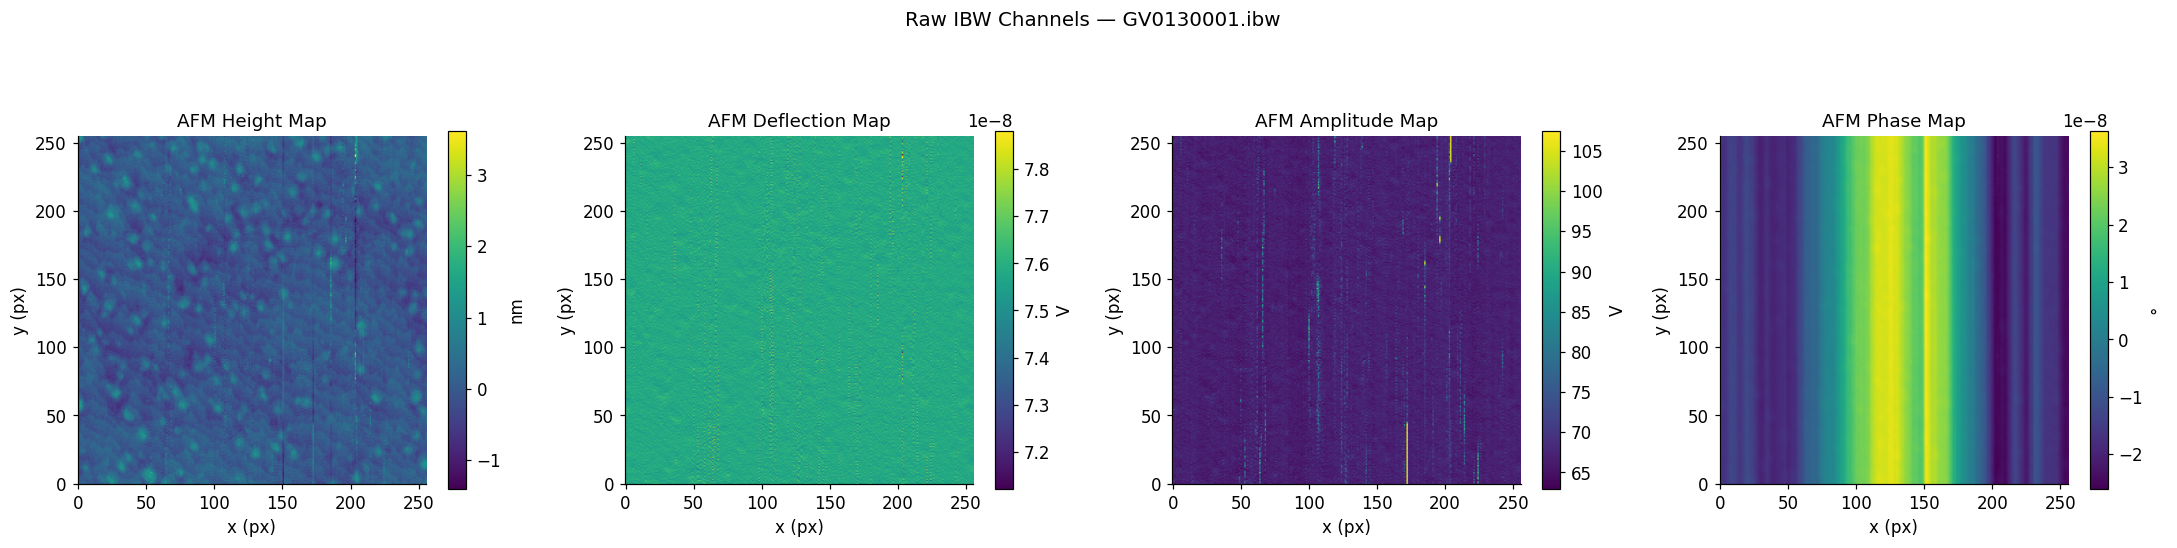

In [32]:
channels = [height, defl, amplitude, phase]
cmaps    = 'viridis'
units    = ['nm', 'V', 'V', '°']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, ch_data, name, unit in zip(
        axes, channels, CHANNEL_NAMES.values(), units):
    im = ax.imshow(ch_data, cmap=cmaps, origin='lower')
    ax.set_title(f"AFM {name} Map", fontsize=12)
    ax.set_xlabel("x (px)"); ax.set_ylabel("y (px)")
    cbar = fig.colorbar(im, ax=ax, shrink=0.75)
    cbar.set_label(unit)

plt.suptitle(f"Raw IBW Channels — {FILE_PATH}", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Parse & Structure Metadata

The IBW note block contains all instrument parameters. We parse it into a dictionary, display it as a DataFrame, then extract the fields most relevant for semantic search — scan size, imaging mode, tip type, setpoint, etc.

These fields get assembled into a semantic metadata string that the CLIP text encoder will embed alongside the user-supplied text.

In [43]:
# ── Parse IBW note (same function as your existing notebook) ────
def parse_metadata(note_bytes):
    meta = {}
    note = note_bytes.decode('utf-8', errors='ignore')
    for line in note.splitlines():
        if ':' in line:
            k, v = line.split(':', 1)
            meta[k.strip()] = v.strip()
    return meta

meta_dict = parse_metadata(raw_note)
meta_df   = pd.DataFrame(meta_dict.items(), columns=["Field", "Value"])

pd.set_option('display.max_rows', 60)
print(f"Total metadata fields: {len(meta_dict)}")
meta_df

Total metadata fields: 834


,Field,Value
0,ScanSize,2e-06
1,FastScanSize,2e-06
2,SlowScanSize,2e-06
3,ScanRate,1.0016
4,XOffset,-1.4224e-06
...,...,...
829,ColorMap 3,VioletOrangeYellow
830,EndHeadTemp,31.5625 C
831,EndScannerTemp,26.1875 C
832,EndHeaterTemp,22.976 C


In [44]:
# ── Extract key fields for semantic text construction ───────────
# These keys cover standard Asylum Research IBW metadata.
# Update field names if your system uses different labels.

def safe_get(d, *keys, default="unknown"):
    """Try multiple possible key names, return first match."""
    for k in keys:
        if k in d:
            return d[k]
    return default

scan_size   = safe_get(meta_dict, 'ScanSize', 'FastScanSize')
scan_rate   = safe_get(meta_dict, 'ScanRate', 'ScanSpeed')
img_mode    = safe_get(meta_dict, 'ImagingMode', 'ACMode', 'ScanMode')
setpoint    = safe_get(meta_dict, 'Setpoint', 'DriveAmplitude')
tip_speed   = safe_get(meta_dict, 'TipVelocity', 'LineRate','ScanRate')
date        = safe_get(meta_dict, 'Date', 'Timestamp')
operator    = safe_get(meta_dict, 'Operator', 'Username', 'User')
resolution  = f"{n_rows}x{n_cols}"

# Try to extract scan size in μm for readability
try:
    scan_size_um = float(scan_size) * 1e6
    scan_size_str = f"{scan_size_um:.3f} μm"
except (ValueError, TypeError):
    scan_size_str = str(scan_size)

print("── Extracted metadata fields ──────────────────────────")
print(f"  Scan size   : {scan_size_str}")
print(f"  Scan rate   : {scan_rate}")
print(f"  Imaging mode: {img_mode}")
print(f"  Setpoint    : {setpoint}")
print(f"  Resolution  : {resolution}")
print(f"  Date        : {date}")
print(f"  Operator    : {operator}")

── Extracted metadata fields ──────────────────────────
  Scan size   : 2.000 μm
  Scan rate   : 1.0016
  Imaging mode: AC Mode
  Setpoint    : 0.0008
  Resolution  : 256x256
  Date        : 2016-11-15
  Operator    : unknown


In [18]:
# ── Build the semantic metadata string ──────────────────────────
# This is what gets embedded by CLIP's text encoder.
# It combines structured metadata fields with the user-supplied context text.

auto_metadata_str = (
    f"AFM image. "
    f"Scan size: {scan_size_str}. "
    f"Resolution: {resolution} pixels. "
    f"Imaging mode: {img_mode}. "
    f"Scan rate: {scan_rate}. "
    f"Date: {date}. "
    f"Operator: {operator}."
)

# Combine auto-parsed metadata with user-supplied context
full_text_for_embedding = f"{USER_TEXT}. {auto_metadata_str}"

print("── Full text string for embedding ─────────────────────")
print(full_text_for_embedding)
print(f"\nCharacter count : {len(full_text_for_embedding)}")
print(f"Word count      : {len(full_text_for_embedding.split())}")
print()
print("Note: CLIP text encoder accepts up to 77 tokens (~50-60 words).")
print(f"Estimated tokens: ~{len(full_text_for_embedding.split())} (within limit ✓)" 
      if len(full_text_for_embedding.split()) < 55 
      else f"Estimated tokens: ~{len(full_text_for_embedding.split())} — consider shortening USER_TEXT")

── Full text string for embedding ─────────────────────
SrTiO3 thin film on SrTiO3 substrate, tapping mode, ambient conditions. AFM image. Scan size: 2.000 μm. Resolution: 256x256 pixels. Imaging mode: AC Mode. Scan rate: 1.0016. Date: 2016-11-15. Operator: unknown.

Character count : 210
Word count      : 30

Note: CLIP text encoder accepts up to 77 tokens (~50-60 words).
Estimated tokens: ~30 (within limit ✓)


## 6. Height Map Preprocessing Pipeline

Before CLIP embedding, the height map must be standardized. Raw AFM images are not directly comparable because:
- Scan sizes vary (0.5 μm vs 5 μm scans have very different pixel scales)  
- Tilt artifacts shift the global height baseline  
- Height value ranges differ between samples  
- CLIP expects a 224×224 RGB uint8 image  

We apply four steps in sequence and visualize each one:

| Step | What it does | Why |
|---|---|---|
| **Plane level** | Subtract least-squares tilt plane | Removes sample mounting tilt |
| **Gentle smoothing** | Gaussian σ=0.8 | Removes single-pixel detector noise |
| **Height normalization** | Scale to [0, 1] using 2nd–98th percentile | Makes images from different samples comparable |
| **Resize + colormap** | 224×224 RGB via `viridis` colormap | Matches CLIP's expected input format |

In [19]:
# ── Step 1: Plane leveling ──────────────────────────────────────
def plane_level(h):
    """Remove least-squares tilt plane from height map."""
    rows, cols = h.shape
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    A = np.column_stack([np.ones(rows * cols), X.ravel(), Y.ravel()])
    coeffs, _, _, _ = np.linalg.lstsq(A, h.ravel(), rcond=None)
    plane = coeffs[0] + coeffs[1] * X + coeffs[2] * Y
    return h - plane, plane, coeffs

h_leveled, plane, coeffs = plane_level(height.astype(float))
print(f"Plane removed — tilt x: {coeffs[1]:.5f} nm/px, y: {coeffs[2]:.5f} nm/px")
print(f"Leveled range : {h_leveled.min():.3f} – {h_leveled.max():.3f} nm")

Plane removed — tilt x: -0.00000 nm/px, y: -0.00000 nm/px
Leveled range : -1.397 – 3.608 nm


In [50]:
# ── Step 2: Gaussian smoothing ──────────────────────────────────
h_smooth = gaussian_filter(h_leveled, sigma=GAUSS_SIGMA)
print(f"Smoothed  (σ={GAUSS_SIGMA}): range {h_smooth.min():.3f} – {h_smooth.max():.3f} nm")

# ── Step 3: Percentile normalization → [0, 1] ───────────────────
p_low  = np.percentile(h_smooth, 2)
p_high = np.percentile(h_smooth, 98)
h_norm = np.clip((h_smooth - p_low) / (p_high - p_low + 1e-12), 0, 1)
print(f"Normalized    : range {h_norm.min():.4f} – {h_norm.max():.4f}  (2nd–98th pct clip)")

# ── Step 4: Resize to 224×224 ───────────────────────────────────
h_resized = resize(h_norm, (CLIP_IMG_SIZE, CLIP_IMG_SIZE),
                   anti_aliasing=True, mode='reflect')
print(f"Resized       : {h_resized.shape}  (target for CLIP)")

# ── Convert to RGB uint8 via viridis colormap ────────────────────
cmap_fn   = plt.get_cmap('viridis')
h_rgb     = (cmap_fn(h_resized)[:, :, :3] * 255).astype(np.uint8)
pil_image = Image.fromarray(h_rgb)

print(f"PIL image     : {pil_image.size}, mode={pil_image.mode}")

Smoothed  (σ=0.8): range -0.881 – 1.595 nm
Normalized    : range 0.0000 – 1.0000  (2nd–98th pct clip)
Resized       : (224, 224)  (target for CLIP)
PIL image     : (224, 224), mode=RGB


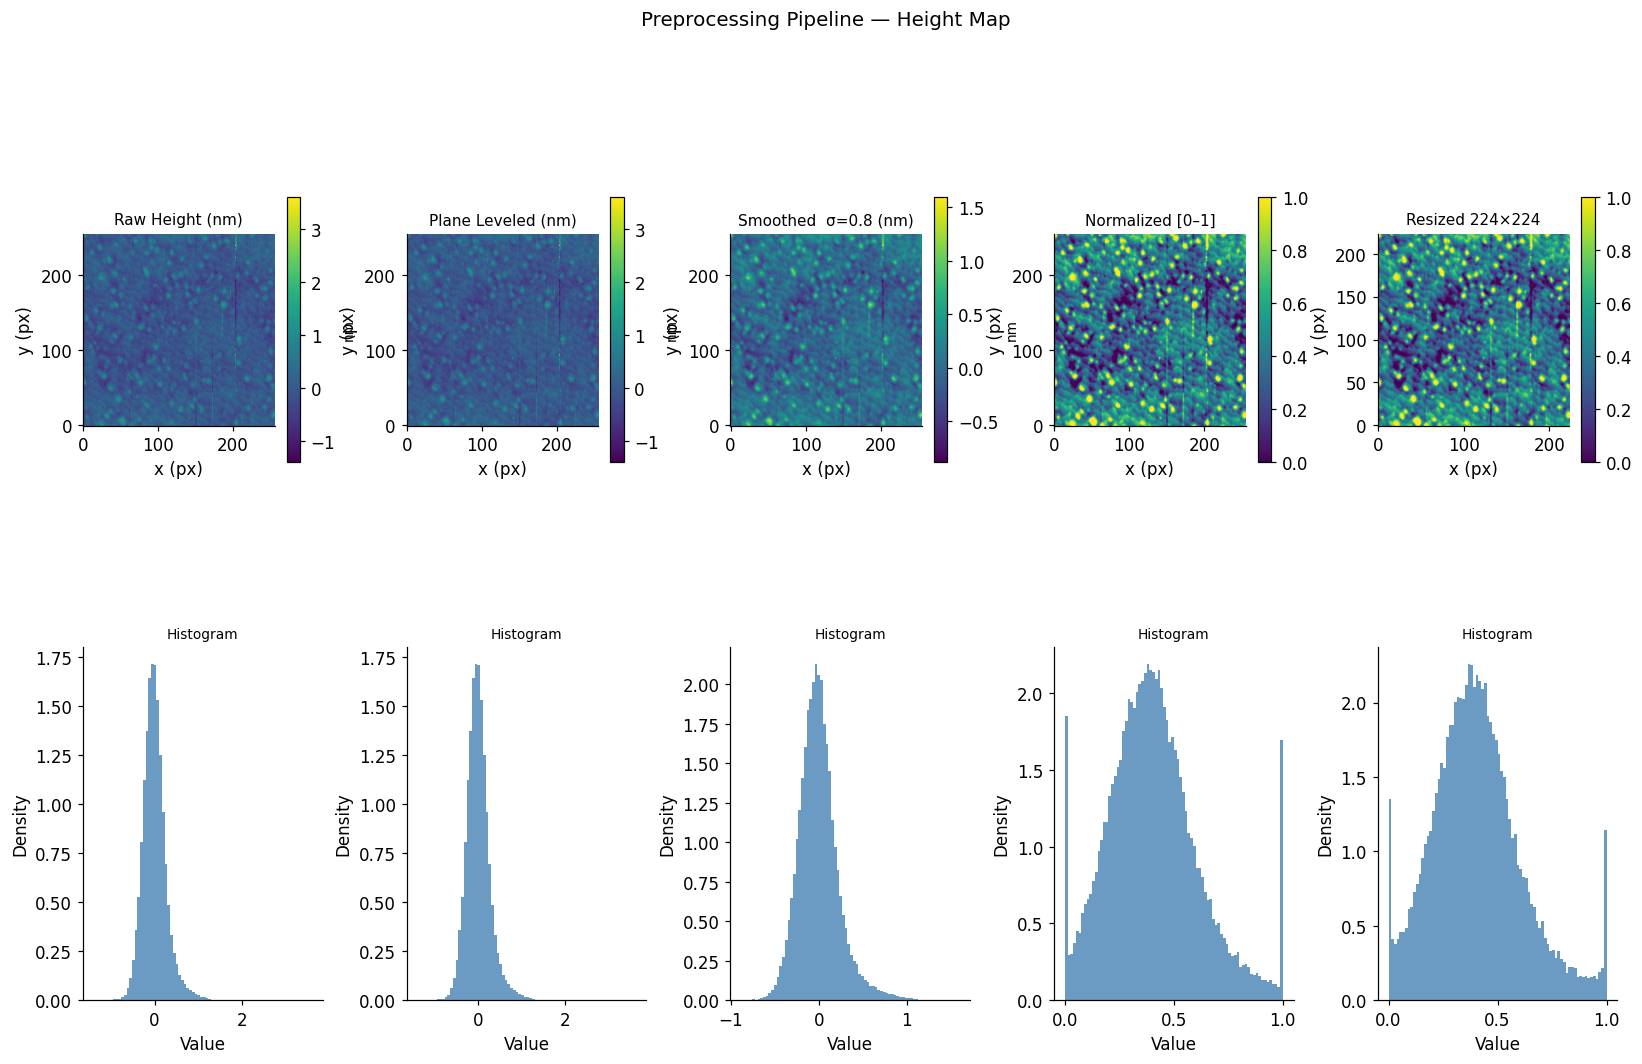

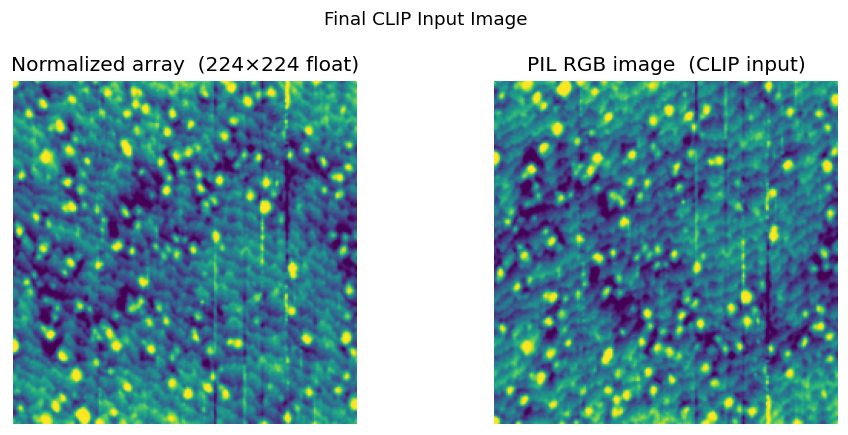

In [51]:
# ── Visualize all preprocessing steps ───────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.4, wspace=0.35)

steps = [
    (height,     'viridis', 'Raw Height (nm)',          True),
    (h_leveled,  'viridis', 'Plane Leveled (nm)',       True),
    (h_smooth,   'viridis', 'Smoothed  σ=0.8 (nm)',     True),
    (h_norm,     'viridis', 'Normalized [0–1]',         False),
    (h_resized,  'viridis', f'Resized {CLIP_IMG_SIZE}×{CLIP_IMG_SIZE}', False),
]

for col, (img, cmap, title, show_nm) in enumerate(steps):
    ax_top = fig.add_subplot(gs[0, col])
    im = ax_top.imshow(img, cmap=cmap, origin='lower')
    ax_top.set_title(title, fontsize=10)
    ax_top.set_xlabel('x (px)'); ax_top.set_ylabel('y (px)')
    cbar = fig.colorbar(im, ax=ax_top, shrink=0.75)
    if show_nm: cbar.set_label('nm', fontsize=9)

    # Histogram below each image
    ax_bot = fig.add_subplot(gs[1, col])
    ax_bot.hist(img.ravel(), bins=80, color='steelblue', alpha=0.8, density=True)
    ax_bot.set_xlabel('Value'); ax_bot.set_ylabel('Density')
    ax_bot.set_title(f'Histogram', fontsize=9)

plt.suptitle('Preprocessing Pipeline — Height Map', fontsize=13, y=1.01)
plt.show()

# ── Side-by-side: normalized array vs RGB PIL image ─────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(h_resized, cmap='viridis', origin='lower')
axes[0].set_title(f'Normalized array  (224×224 float)')
axes[0].axis('off')
axes[1].imshow(np.array(pil_image), origin='upper')
axes[1].set_title('PIL RGB image  (CLIP input)')
axes[1].axis('off')
plt.suptitle('Final CLIP Input Image', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Load CLIP Model

We use OpenAI's `ViT-B/32` — the standard CLIP model. It has two encoders:
- **Image encoder** — takes a 224×224 RGB image, outputs a 512-dimensional vector
- **Text encoder** — takes a tokenized string (≤77 tokens), outputs a 512-dimensional vector

Both encoders are trained jointly so that matching image-text pairs have high cosine similarity in the shared 512-d space. This is what makes multimodal search possible — image and text embeddings are directly comparable.

In [22]:
# ── Load CLIP ViT-B/32 ──────────────────────────────────────────
print("Loading CLIP ViT-B/32 ...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()   # inference only — no gradients needed

print(f"Model loaded on : {device}")
print(f"Embedding dim   : 512  (ViT-B/32 output)")
print()
print("CLIP preprocessing pipeline (built-in):")
print(clip_preprocess)

Loading CLIP ViT-B/32 ...


100%|███████████████████████████████████████| 338M/338M [01:07<00:00, 5.28MiB/s]


Model loaded on : cpu
Embedding dim   : 512  (ViT-B/32 output)

CLIP preprocessing pipeline (built-in):
Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x0000022E4AF49EE0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


## 8. Generate Image Embedding

The PIL image produced in Step 6 is passed through CLIP's built-in preprocessing transform (resize, center crop, normalize to ImageNet stats) and then through the image encoder.

The output is a **512-dimensional unit vector** — the image's fingerprint in CLIP's shared embedding space.

In [23]:
# ── Apply CLIP's own preprocessing on top of our PIL image ──────
clip_input = clip_preprocess(pil_image).unsqueeze(0).to(device)
print(f"CLIP input tensor shape: {clip_input.shape}")   # (1, 3, 224, 224)

# ── Encode image ────────────────────────────────────────────────
with torch.no_grad():
    image_features = clip_model.encode_image(clip_input)

# ── L2-normalize → unit vector (standard for cosine similarity) ─
image_embedding = image_features / image_features.norm(dim=-1, keepdim=True)
image_vec = image_embedding.cpu().numpy().squeeze()   # shape: (512,)

print(f"Image embedding shape  : {image_vec.shape}")
print(f"L2 norm (should be 1.0): {np.linalg.norm(image_vec):.6f}")
print(f"Value range            : [{image_vec.min():.4f}, {image_vec.max():.4f}]")

CLIP input tensor shape: torch.Size([1, 3, 224, 224])
Image embedding shape  : (512,)
L2 norm (should be 1.0): 1.000000
Value range            : [-0.6482, 0.2425]


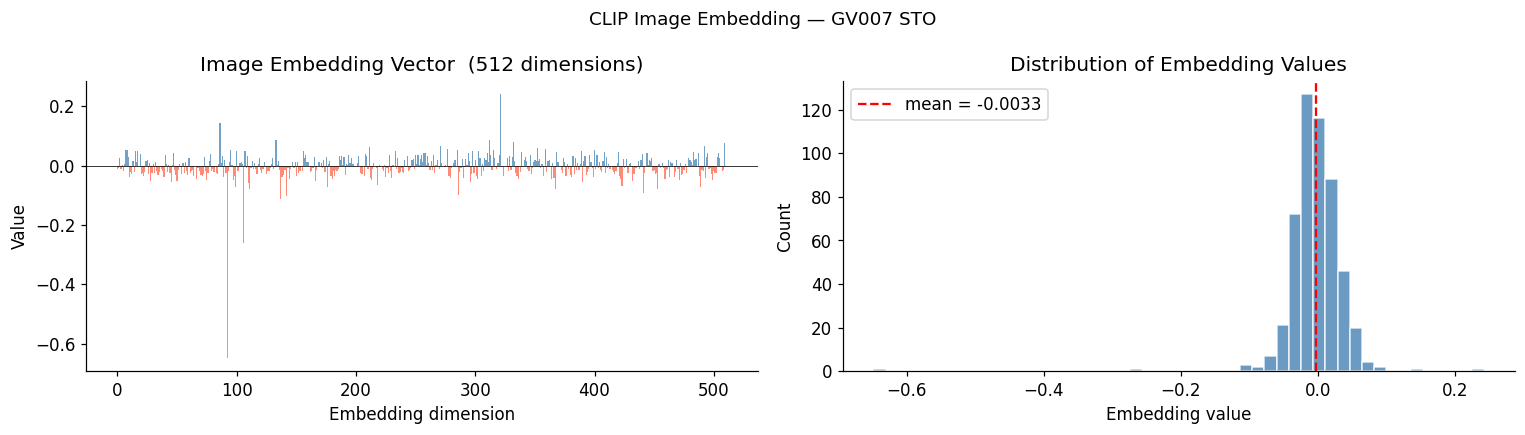

In [24]:
# ── Visualize the image embedding vector ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full 512-d vector as bar chart
axes[0].bar(np.arange(len(image_vec)), image_vec,
            color=np.where(image_vec > 0, 'steelblue', 'tomato'), alpha=0.75, width=1.0)
axes[0].set_xlabel('Embedding dimension'); axes[0].set_ylabel('Value')
axes[0].set_title('Image Embedding Vector  (512 dimensions)')
axes[0].axhline(0, color='black', lw=0.5)

# Distribution of values
axes[1].hist(image_vec, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Embedding value'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Embedding Values')
axes[1].axvline(image_vec.mean(), color='red', ls='--', lw=1.5,
                label=f'mean = {image_vec.mean():.4f}')
axes[1].legend()

plt.suptitle('CLIP Image Embedding — GV007 STO', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Generate Text Embedding

The full text string (user context + parsed metadata) is tokenized by CLIP's tokenizer and passed through the text encoder. The output is another **512-dimensional unit vector** in the same embedding space as the image vector.

The cosine similarity between the image and text embeddings tells us how well the text describes the image — a value near 1.0 means strong alignment.

In [25]:
# ── Tokenize ────────────────────────────────────────────────────
# CLIP truncates at 77 tokens automatically
text_tokens = clip.tokenize([full_text_for_embedding],
                             truncate=True).to(device)
print(f"Token tensor shape: {text_tokens.shape}")   # (1, 77)
print(f"Non-padding tokens: {(text_tokens > 0).sum().item()}")

# ── Encode text ─────────────────────────────────────────────────
with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)

text_embedding = text_features / text_features.norm(dim=-1, keepdim=True)
text_vec = text_embedding.cpu().numpy().squeeze()   # shape: (512,)

print(f"\nText embedding shape   : {text_vec.shape}")
print(f"L2 norm (should be 1.0): {np.linalg.norm(text_vec):.6f}")
print(f"Value range            : [{text_vec.min():.4f}, {text_vec.max():.4f}]")

Token tensor shape: torch.Size([1, 77])
Non-padding tokens: 77

Text embedding shape   : (512,)
L2 norm (should be 1.0): 1.000000
Value range            : [-0.1230, 0.4002]


In [26]:
# ── Compute image–text cosine similarity ────────────────────────
# Since both vectors are L2-normalized, dot product = cosine similarity
cosine_sim = float(np.dot(image_vec, text_vec))

print(f"Image–text cosine similarity: {cosine_sim:.4f}")
print()
if   cosine_sim > 0.30: print("  ✓ Strong alignment — text describes image well")
elif cosine_sim > 0.20: print("  ~ Moderate alignment — partial match")
else:                   print("  ✗ Weak alignment — text may not match this image type")
print()
print("Note: CLIP image–text similarities are typically in the 0.15–0.35 range.")
print("Cross-image cosine similarity (image vs image) is typically 0.8–0.99.")

Image–text cosine similarity: 0.3255

  ✓ Strong alignment — text describes image well

Note: CLIP image–text similarities are typically in the 0.15–0.35 range.
Cross-image cosine similarity (image vs image) is typically 0.8–0.99.


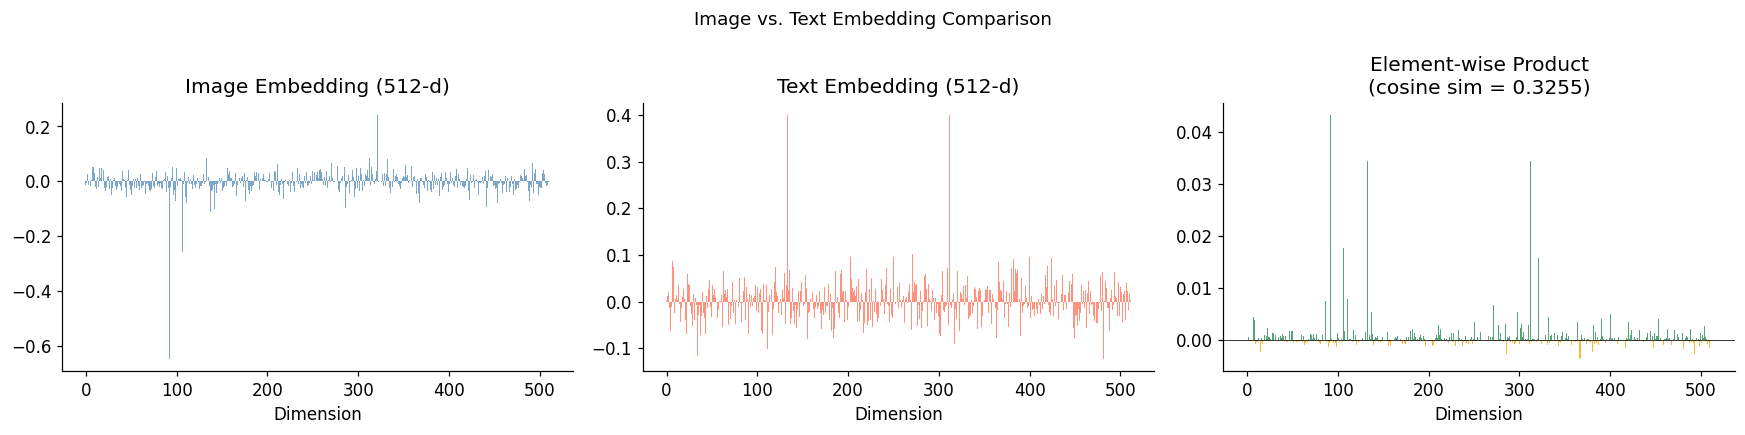

In [27]:
# ── Side-by-side embedding comparison ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(np.arange(512), image_vec, color='steelblue', alpha=0.7, width=1.0)
axes[0].set_title('Image Embedding (512-d)'); axes[0].set_xlabel('Dimension')

axes[1].bar(np.arange(512), text_vec, color='tomato', alpha=0.7, width=1.0)
axes[1].set_title('Text Embedding (512-d)'); axes[1].set_xlabel('Dimension')

# Element-wise product highlights dimensions where they agree
agreement = image_vec * text_vec
axes[2].bar(np.arange(512), agreement,
            color=np.where(agreement > 0, 'seagreen', 'orange'), alpha=0.8, width=1.0)
axes[2].set_title(f'Element-wise Product\n(cosine sim = {cosine_sim:.4f})')
axes[2].set_xlabel('Dimension')
axes[2].axhline(0, color='black', lw=0.5)

plt.suptitle('Image vs. Text Embedding Comparison', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Text Query Probe — Semantic Sensitivity Check

A key validation step: we check whether the CLIP embeddings are semantically meaningful for AFM/materials science language. We compare the image embedding against several text descriptions to see if correct descriptions score higher than incorrect ones.

This is a direct preview of how the similarity search will rank results at query time.

Query                                                     Cosine Sim
----------------------------------------------------------------------
AFM height map of a thin film surface                     0.3112  ██████████████████████████████████████████████████████████████
SrTiO3 perovskite oxide thin film substrate AFM scan      0.2930  ██████████████████████████████████████████████████████████
atomic force microscopy surface topography nanoscale      0.2968  ███████████████████████████████████████████████████████████
X-ray diffraction pattern of crystalline material         0.3033  ████████████████████████████████████████████████████████████
transmission electron microscopy cross-section image      0.2835  ████████████████████████████████████████████████████████
photograph of a mountain landscape                        0.2295  █████████████████████████████████████████████
random noise signal                                       0.2689  ████████████████████████████████████████████████████

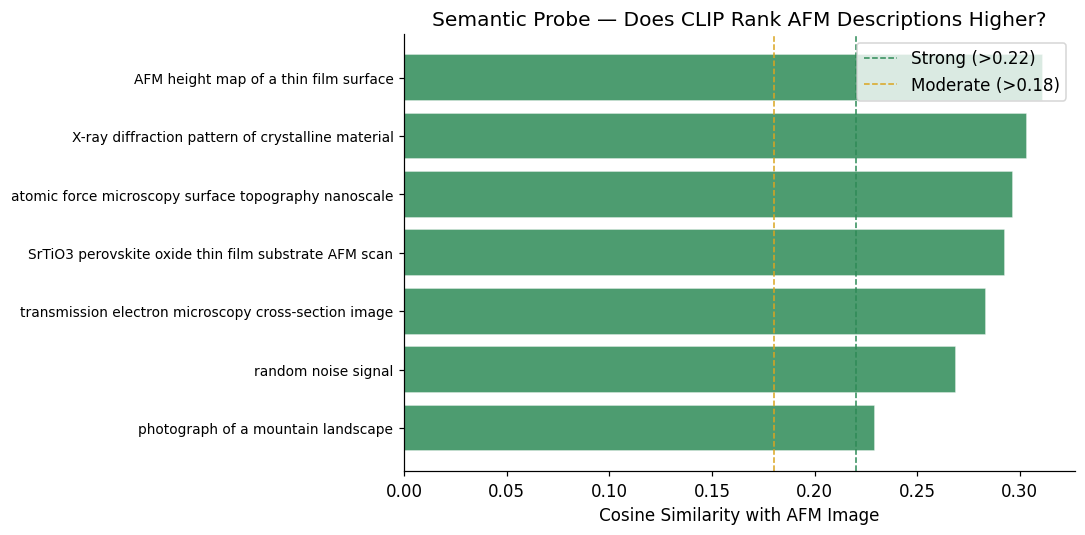

In [28]:
probe_queries = [
    # Expected high similarity
    "AFM height map of a thin film surface",
    "SrTiO3 perovskite oxide thin film substrate AFM scan",
    "atomic force microscopy surface topography nanoscale",
    # Expected lower similarity
    "X-ray diffraction pattern of crystalline material",
    "transmission electron microscopy cross-section image",
    "photograph of a mountain landscape",
    "random noise signal",
]

print(f"{'Query':<55} {'Cosine Sim':>12}")
print("-" * 70)

results = []
for query in probe_queries:
    tokens = clip.tokenize([query], truncate=True).to(device)
    with torch.no_grad():
        feat = clip_model.encode_text(tokens)
    feat = feat / feat.norm(dim=-1, keepdim=True)
    sim  = float(np.dot(image_vec, feat.cpu().numpy().squeeze()))
    results.append((query, sim))
    bar = '█' * int(sim * 200)
    print(f"{query:<55} {sim:>8.4f}  {bar}")

# ── Bar chart ───────────────────────────────────────────────────
queries, sims = zip(*sorted(results, key=lambda x: x[1], reverse=True))
colors = ['seagreen' if s > 0.22 else ('goldenrod' if s > 0.18 else 'tomato')
          for s in sims]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(queries)), sims, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(queries)))
ax.set_yticklabels([q[:52] + '…' if len(q) > 52 else q for q in queries], fontsize=9)
ax.set_xlabel('Cosine Similarity with AFM Image')
ax.set_title('Semantic Probe — Does CLIP Rank AFM Descriptions Higher?')
ax.axvline(0.22, color='seagreen', ls='--', lw=1, label='Strong (>0.22)')
ax.axvline(0.18, color='goldenrod', ls='--', lw=1, label='Moderate (>0.18)')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## 11. Package Ingestion Record

All outputs are bundled into a single Python dictionary — one record per `.ibw` file. This is the object that gets written to the vector database in the next pipeline stage (e.g. Neo4j).

**What goes into the record:**

| Field | Type | Used for |
|---|---|---|
| `file_path` | str | Provenance, retrieval |
| `image_embedding` | np.ndarray (512,) | Vector similarity search |
| `text_embedding` | np.ndarray (512,) | Text query matching |
| `metadata` | dict | Filtered display, graph relationships |
| `user_text` | str | Display, re-embedding |
| `full_text` | str | Display, debugging |
| `image_text_similarity` | float | Quality check flag |
| `preprocessed_image_array` | np.ndarray (224,224) | Visual thumbnail |

In [29]:
import json
from datetime import datetime

ingestion_record = {
    # ── Provenance ───────────────────────────────────────────
    "file_path"              : FILE_PATH,
    "ingestion_timestamp"    : datetime.now().isoformat(),

    # ── Embeddings (these go into the vector DB) ─────────────
    "image_embedding"        : image_vec,           # np.ndarray (512,)
    "text_embedding"         : text_vec,            # np.ndarray (512,)

    # ── Metadata ─────────────────────────────────────────────
    "metadata_raw"           : meta_dict,           # full parsed IBW note
    "metadata_structured"    : {                    # key fields only
        "scan_size"          : scan_size_str,
        "resolution"         : resolution,
        "imaging_mode"       : img_mode,
        "scan_rate"          : scan_rate,
        "date"               : date,
        "operator"           : operator,
    },

    # ── Text ─────────────────────────────────────────────────
    "user_text"              : USER_TEXT,
    "full_text_embedded"     : full_text_for_embedding,

    # ── Quality metrics ──────────────────────────────────────
    "image_text_similarity"  : cosine_sim,
    "embedding_dim"          : len(image_vec),
    "clip_model"             : "ViT-B/32",

    # ── Preprocessed image (thumbnail for display) ───────────
    "preprocessed_array"     : h_resized,           # (224, 224) float
}

print("── Ingestion Record Summary ────────────────────────────")
for k, v in ingestion_record.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:<30} np.ndarray  shape={v.shape}, dtype={v.dtype}")
    elif isinstance(v, dict):
        print(f"  {k:<30} dict  ({len(v)} keys)")
    else:
        print(f"  {k:<30} {str(v)[:60]}")

── Ingestion Record Summary ────────────────────────────
  file_path                      GV0130001.ibw
  ingestion_timestamp            2026-03-12T09:57:44.804256
  image_embedding                np.ndarray  shape=(512,), dtype=float32
  text_embedding                 np.ndarray  shape=(512,), dtype=float32
  metadata_raw                   dict  (834 keys)
  metadata_structured            dict  (6 keys)
  user_text                      SrTiO3 thin film on SrTiO3 substrate, tapping mode, ambient 
  full_text_embedded             SrTiO3 thin film on SrTiO3 substrate, tapping mode, ambient 
  image_text_similarity          0.32549113035202026
  embedding_dim                  512
  clip_model                     ViT-B/32
  preprocessed_array             np.ndarray  shape=(224, 224), dtype=float64


In [30]:
# ── Save embeddings to .npz for next pipeline stage ─────────────
output_stem = FILE_PATH.replace('.ibw', '')
npz_path    = f"{output_stem}_ingestion.npz"

np.savez(npz_path,
    image_embedding      = ingestion_record['image_embedding'],
    text_embedding       = ingestion_record['text_embedding'],
    preprocessed_array   = ingestion_record['preprocessed_array'],
)

# ── Save metadata to JSON ────────────────────────────────────────
json_path = f"{output_stem}_metadata.json"
json_safe_meta = {
    "file_path"            : ingestion_record['file_path'],
    "ingestion_timestamp"  : ingestion_record['ingestion_timestamp'],
    "user_text"            : ingestion_record['user_text'],
    "full_text_embedded"   : ingestion_record['full_text_embedded'],
    "image_text_similarity": ingestion_record['image_text_similarity'],
    "clip_model"           : ingestion_record['clip_model'],
    "embedding_dim"        : ingestion_record['embedding_dim'],
    "metadata_structured"  : ingestion_record['metadata_structured'],
}
with open(json_path, 'w') as f:
    json.dump(json_safe_meta, f, indent=2)

print(f"Embeddings saved → {npz_path}")
print(f"Metadata saved   → {json_path}")
print()
print("These two files are the input to the vector DB ingestion script (next stage).")

Embeddings saved → GV0130001_ingestion.npz
Metadata saved   → GV0130001_metadata.json

These two files are the input to the vector DB ingestion script (next stage).
